# Privision de la frequence du reseau de la SENELEC

### Importation des packages

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.utils import resample


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

### Importation de la base de donnée

In [53]:
frequence_classique = pd.read_excel('Delestage_annuelle_2019.xlsx',parse_dates=True, index_col=[0])

frequence_classique.head()

,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW),Frequence (Hz)
Heure,,,,,,,
2019-01-01 01:00:00,636.930263,430.407707,0.0,0.0,0.0,0.0,50.109
2019-01-01 02:00:00,636.930263,406.129563,0.0,0.0,0.0,0.0,49.939
2019-01-01 03:00:00,636.930263,372.603857,0.0,0.0,0.0,0.0,50.281
2019-01-01 04:00:00,636.930263,356.614000,0.0,0.0,3.3,3.3,50.365
2019-01-01 05:00:00,636.930263,352.424888,0.0,0.0,0.0,0.0,50.199


In [54]:
frequence_classique['Frequence_cat'] = frequence_classique['Frequence (Hz)'].apply(lambda x: 1 if 49.7 <= x <= 50.3 else 0)
frequence_classique.head()

,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW),Frequence (Hz),Frequence_cat
Heure,,,,,,,,
2019-01-01 01:00:00,636.930263,430.407707,0.0,0.0,0.0,0.0,50.109,1
2019-01-01 02:00:00,636.930263,406.129563,0.0,0.0,0.0,0.0,49.939,1
2019-01-01 03:00:00,636.930263,372.603857,0.0,0.0,0.0,0.0,50.281,1
2019-01-01 04:00:00,636.930263,356.614000,0.0,0.0,3.3,3.3,50.365,0
2019-01-01 05:00:00,636.930263,352.424888,0.0,0.0,0.0,0.0,50.199,1


In [55]:
frequence_classique.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9774 entries, 2019-01-01 01:00:00 to 2020-02-12 06:00:00
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   P.dispo (MW)                   9774 non-null   float64
 1   Demande (MW)                   9774 non-null   float64
 2   Délest par Manque Product      9774 non-null   float64
 3   P. Effacée (MW)                9774 non-null   float64
 4   Autres         P. coupée (MW)  9774 non-null   float64
 5   Déficit total (MW)             9774 non-null   float64
 6   Frequence (Hz)                 7768 non-null   float64
 7   Frequence_cat                  9774 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 687.2 KB


In [56]:
frequence_classique.isnull().sum()

P.dispo (MW)                        0
Demande (MW)                        0
Délest par Manque Product           0
P. Effacée (MW)                     0
Autres         P. coupée (MW)       0
Déficit total (MW)                  0
Frequence (Hz)                   2006
Frequence_cat                       0
dtype: int64

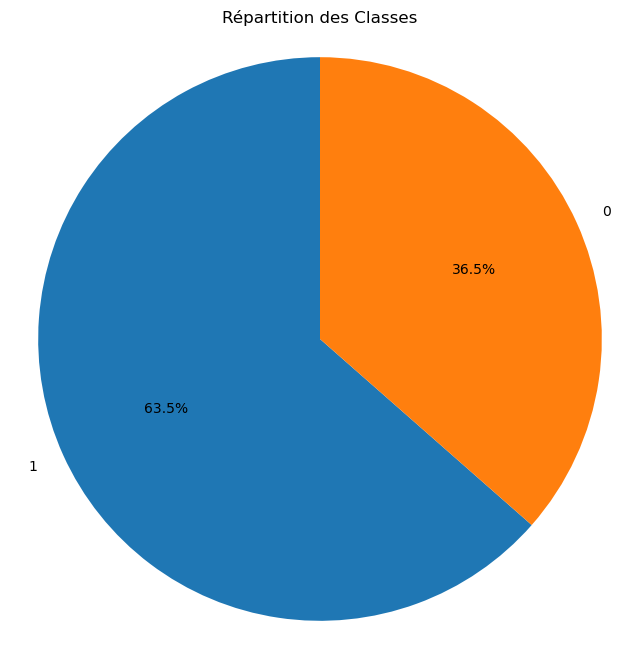

In [57]:
import matplotlib.pyplot as plt

# Supposons une variable catégorique
counts = frequence_classique["Frequence_cat"].value_counts()

# Diagramme circulaire
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',startangle=90)
plt.title("Répartition des Classes")
plt.axis('equal')  # cercle parfait
plt.show()

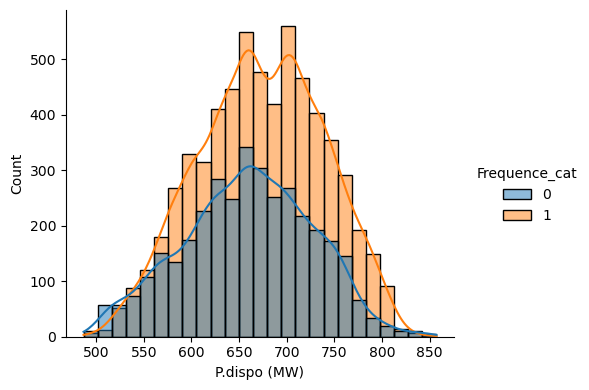

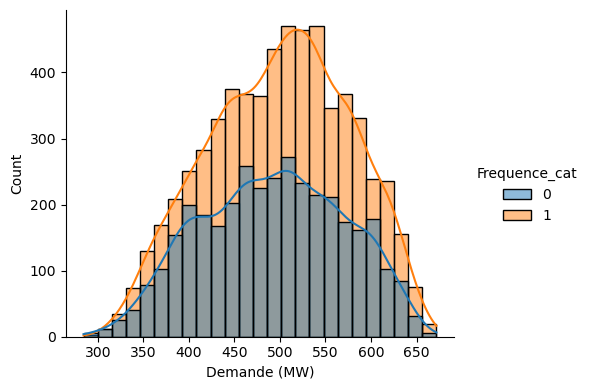

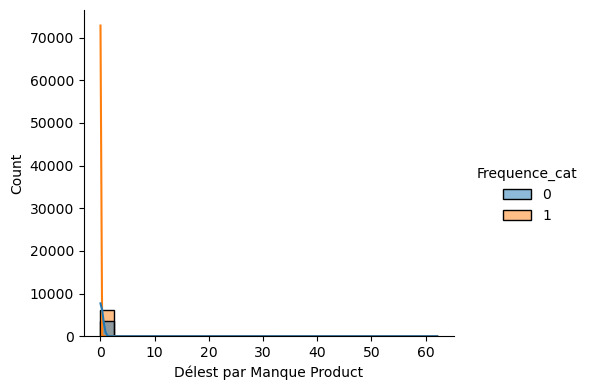

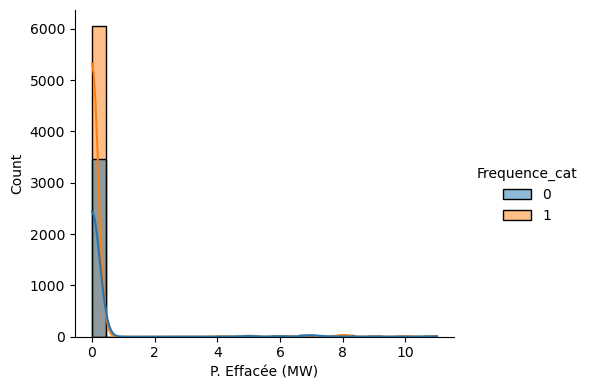

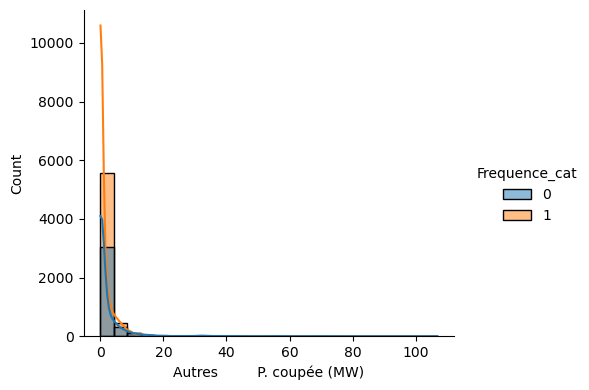

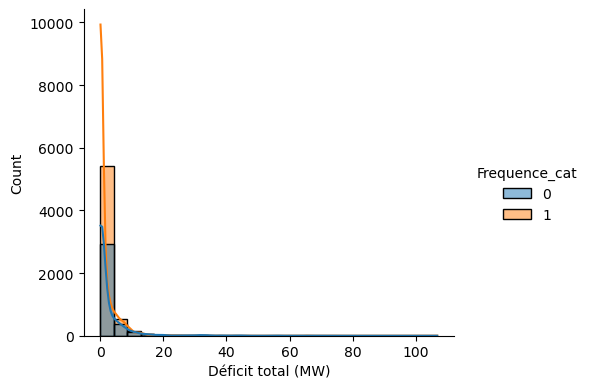

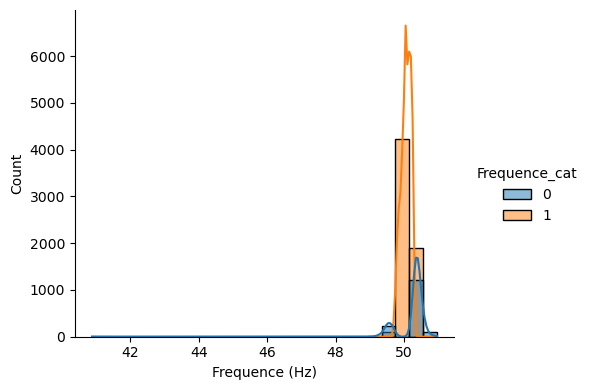

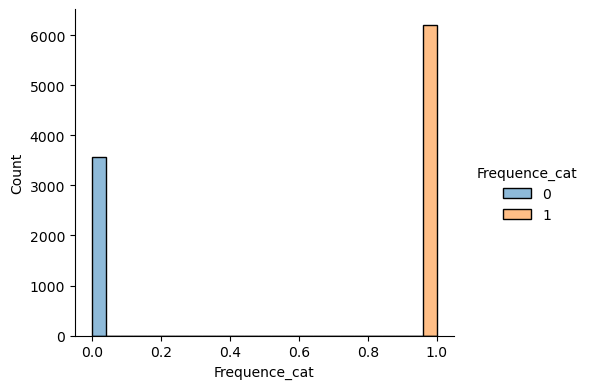

In [58]:
for i in frequence_classique.columns:
    sns.displot(
    data=frequence_classique,
    x=i,
    hue="Frequence_cat",
    kind='hist',
    bins=25,
    kde=True,
    height=4,
    aspect=1.2)


<Axes: xlabel='P.dispo (MW)', ylabel='Demande (MW)'>

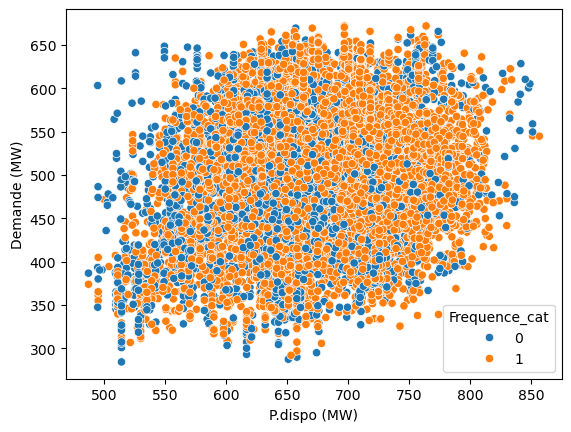

In [31]:
sns.scatterplot(data=frequence_classique, x='P.dispo (MW)', y='Demande (MW)', hue='Frequence_cat')

### Traitement des données

In [59]:
X= frequence_classique.drop(columns=['Frequence (Hz)','Frequence_cat'],axis=1) # variables explicatifs

y= frequence_classique[['Frequence_cat']] # variable cibre

seed =1111

In [76]:
# 2. Séparer les données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed,stratify=y)

# sepatation en données de teste et de validation
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=seed,stratify=y_test)

In [77]:
X_train

,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW)
Heure,,,,,,
2019-06-12 06:00:00,539.000000,450.090929,0.0,0.0,0.00,0.00
2019-01-03 04:00:00,544.850000,540.241777,0.0,4.0,0.00,4.00
2019-11-11 13:00:00,770.864917,595.136102,0.0,0.0,0.00,0.00
2019-03-12 02:00:00,676.096857,373.915631,0.0,0.0,0.00,0.00
2019-05-19 02:00:00,735.850000,488.788979,0.0,0.0,0.70,0.70
...,...,...,...,...,...,...
2019-02-16 17:00:00,741.155833,481.475950,0.0,0.0,1.05,1.05
2019-11-16 06:00:00,705.400000,610.348715,0.0,0.0,0.00,0.00
2020-01-14 09:00:00,758.139000,409.180238,0.0,0.0,2.80,2.80


In [62]:
# verification de la frequence des classes dans y
pd.DataFrame(y).value_counts(normalize=True)

Frequence_cat
1                0.635257
0                0.364743
Name: proportion, dtype: float64

In [63]:
# verification de la frequence des classes dans y_train
pd.DataFrame(y_train).value_counts(normalize=True)

Frequence_cat
1                0.635247
0                0.364753
Name: proportion, dtype: float64

In [64]:
# verification de la frequence des classes dans y_val
pd.DataFrame(y_val).value_counts(normalize=True)

Frequence_cat
1                0.635619
0                0.364381
Name: proportion, dtype: float64

#### Resolution des problemes de desequilibre entre les classes

In [65]:
x2 = X_train
x2["Frequence_cat"] = y_train.values

# La classe mimoritaire
minority = x2[x2.Frequence_cat == 0]

# La classe mojoritaire
majority = x2[x2.Frequence_cat == 1]

##### La Methode du sur echantillonnage

In [66]:
minority_upsample = resample(minority,replace=True,n_samples=len(majority),random_state=seed)

sur_echantillon = pd.concat([majority,minority_upsample])

# verification des proportions
print(sur_echantillon['Frequence_cat'].value_counts(normalize = True))

# Données  d'entrainement
X_train_up = sur_echantillon.drop('Frequence_cat',axis=1)
y_train_up = sur_echantillon[['Frequence_cat']]

Frequence_cat
1    0.5
0    0.5
Name: proportion, dtype: float64


##### La Methode du sous echantilionnagr

In [67]:
majority_downsample = resample(majority,replace=False,n_samples=len(minority),random_state=seed)
sous_echantillionnage = pd.concat([majority_downsample,minority])
print(sous_echantillionnage['Frequence_cat'].value_counts(normalize = True))

# Donnees d'entrainement sous le sous echantillionnage
X_train_down = sous_echantillionnage.drop('Frequence_cat',axis=1)
y_train_down = sous_echantillionnage[['Frequence_cat']]

Frequence_cat
1    0.5
0    0.5
Name: proportion, dtype: float64


In [78]:
train_features = X_train
train_labels = y_train

#### Normalisation des données

In [79]:
scaler =MinMaxScaler()
mode_scaler = scaler.fit(train_features)
train_features = mode_scaler.fit_transform(train_features)
X_val = mode_scaler.fit_transform(X_val)
X_test = mode_scaler.fit_transform(X_test)

In [80]:
train_features.shape

(7819, 6)

In [81]:
X.shape

(9774, 6)

In [82]:
train_features = pd.DataFrame(train_features,columns=X.columns)
X_val = pd.DataFrame(X_val,columns=X.columns)
X_test = pd.DataFrame(X_test,columns=X.columns)

### Modelisation par Machine learning

##### La regression logistique

In [83]:
def modele_log_evalution(modele,features,labels):
    pred = modele.predict(features)
    print(classification_report(labels,pred))
    return pred

def model_with_ref(modele):
    rfe_modele = RFE(estimator=modele,verbose=0)
    rfe_modele.fit(train_features,train_labels)
    mask = rfe_modele.support_
    reduced_X = train_features.loc[:,mask]
    print(reduced_X.columns)
    return rfe_modele

from sklearn.metrics import precision_score,recall_score, precision_recall_curve,f1_score
def performances(y_val,pred,sample_weights= None):
    precission = precision_score(y_val,pred, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')


    rappel = recall_score(y_val,pred, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')
    

    f1 = f1_score(y_val,pred, pos_label=1)
    print(f"F1-score: {f1:.2f}")

    print(f"La precision est : {precission:.2f}\n Le rappel : {rappel:.2f}")

    precision, recall, thresholds = precision_recall_curve(y_val,pred)

    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.grid()
    plt.show()

LogisticRegression(C=100, max_iter=500, random_state=1111)
_________________
0.7784663026020026
              precision    recall  f1-score   support

           0       0.52      0.06      0.12       356
           1       0.64      0.97      0.77       621

    accuracy                           0.64       977
   macro avg       0.58      0.52      0.44       977
weighted avg       0.60      0.64      0.53       977



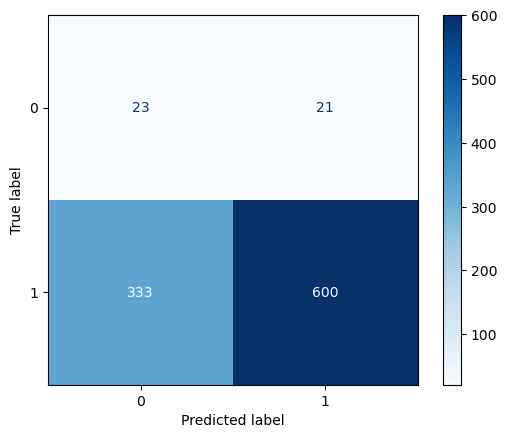

In [84]:
# dictionnaire des hyperparametres
param_hyper = {'C': [0.001,0.01,1,50,100,500]}

#Objet GridSearchcv
grid_logie = GridSearchCV(estimator=LogisticRegression(
    random_state=seed,max_iter=500),param_grid = param_hyper,scoring ='f1', cv = 5,verbose=0)
# Entraiment du modele
logi_modele = grid_logie.fit(train_features,train_labels)

print(logi_modele.best_estimator_)
print("_________________")
print(logi_modele.best_score_)

pred = modele_log_evalution(logi_modele.best_estimator_,X_val,y_val)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(pred,y_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues")


F1-score: 0.77
La precision est : 0.97
 Le rappel : 0.64


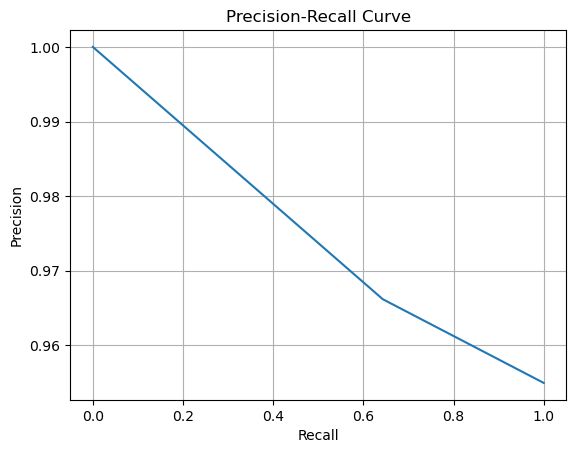

In [85]:
performances(pred,y_val)

  0%|          | 0/977 [00:00<?, ?it/s]

shap_values[1] shape: (977, 6, 2)
X_val shape: (977, 6)


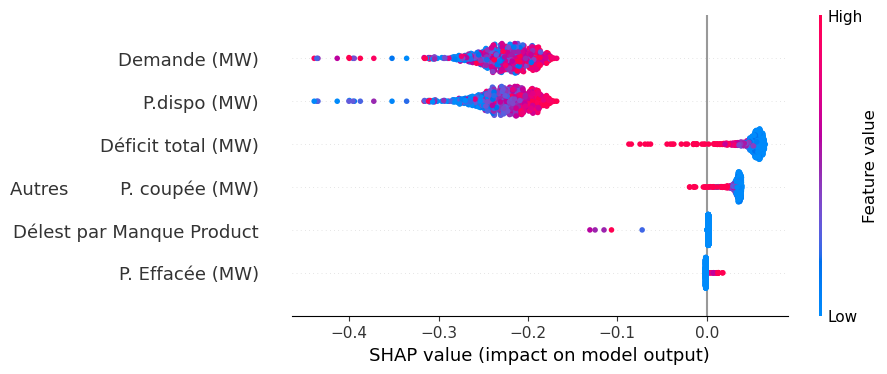

In [86]:
import shap
# Explainer SHAP : KernelExplainer car modèle linéaire
explainer = shap.KernelExplainer(logi_modele.best_estimator_.predict_proba, X_train.sample(100))

# Calcul des SHAP values pour quelques lignes
shap_values = explainer.shap_values(X_val)


print("shap_values[1] shape:", shap_values.shape)
print("X_val shape:", X_val.shape)

shap_class1 = shap_values[:, :, 1]
shap.plots.beeswarm(shap.Explanation(
    values=shap_class1 ,  # SHAP values pour la classe 1
    base_values=explainer.expected_value[1],
    data=X_val.values,
    feature_names=X_val.columns.to_list()
))

Ah, voici un diagramme de type "beeswarm" ou "violin plot" basé sur les valeurs SHAP (SHapley Additive exPlanations). Il nous donne une vue plus détaillée de l'impact de chaque variable sur la prédiction du modèle pour un ensemble d'échantillons. Décortiquons-le ensemble :

Axe horizontal (SHAP value): Cet axe représente l'impact de chaque variable sur la sortie du modèle.

Les valeurs à gauche de zéro indiquent un impact négatif sur la prédiction (la variable tend à diminuer la valeur prédite).
Les valeurs à droite de zéro indiquent un impact positif sur la prédiction (la variable tend à augmenter la valeur prédite).
Axe vertical (Variables): Chaque ligne horizontale correspond à une variable différente. Les variables sont les mêmes que dans le diagramme précédent : Demande (MW), P.dispo (MW), Déficit total (MW), Autres P. coupée (MW), P. Effacée (MW), et Délest par Manque Product.

Points colorés: Chaque point sur le graphique représente un échantillon (une observation) du jeu de données.

La couleur du point indique la valeur de cette variable pour cet échantillon, selon la légende à droite ("Feature value"). Le rouge indique une valeur élevée de la variable, et le bleu indique une valeur faible.
La position horizontale du point indique l'impact de cette valeur de variable sur la prédiction pour cet échantillon spécifique.
Interprétation pour chaque variable :

Demande (MW): On observe une concentration de points rouges (demande élevée) sur la gauche de zéro. Cela suggère qu'une demande élevée a tendance à avoir un impact négatif sur la prédiction du modèle. Les points bleus (demande faible) sont plus dispersés autour de zéro, indiquant un impact plus variable mais généralement plus proche de zéro.

P.dispo (MW): Ici, les points rouges (disponibilité élevée) sont majoritairement situés à gauche de zéro, indiquant qu'une disponibilité de puissance élevée tend à avoir un impact négatif sur la prédiction. Les points bleus (disponibilité faible) sont plus à droite, suggérant un impact positif.

Déficit total (MW): La plupart des points bleus (déficit faible ou nul) sont concentrés légèrement à droite de zéro, indiquant qu'un faible déficit total a un impact positif sur la prédiction. Les quelques points rouges (déficit élevé) sont situés à gauche, suggérant un impact négatif. La distribution est assez asymétrique, avec la majorité des échantillons ayant un déficit faible.

Autres P. coupée (MW): Similaire au déficit total, les points bleus (faible ou pas d'autre puissance coupée) sont principalement à droite de zéro, indiquant un impact positif d'une faible autre puissance coupée sur la prédiction. Les points rouges (puissance coupée élevée) sont à gauche, indiquant un impact négatif.

P. Effacée (MW): La plupart des points sont concentrés autour de zéro, avec une légère tendance des points bleus (faible puissance effacée) à être légèrement à droite, suggérant un impact positif faible d'une faible puissance effacée. Les points rouges (puissance effacée élevée) sont plus dispersés.

Délest par Manque Product: La majorité des points sont très proches de zéro, indiquant que cette variable a généralement un impact faible sur la prédiction, quelle que soit sa valeur (bleu ou rouge).

En résumé :

Ce diagramme nous donne une vision plus nuancée de l'influence de chaque variable sur la prédiction du modèle à travers différents échantillons. On confirme les tendances observées dans le diagramme de Waterfall (demande et disponibilité impactent négativement, déficit et autre puissance coupée impactent positivement quand ils sont faibles). De plus, on voit la distribution de ces impacts et comment ils varient en fonction des valeurs spécifiques de chaque variable pour chaque observation.

Pour une interprétation encore plus précise, connaître la variable cible du modèle reste essentiel. Cela nous permettrait de comprendre le sens de ces impacts positifs et négatifs dans le contexte du problème que le modèle essaie de résoudre

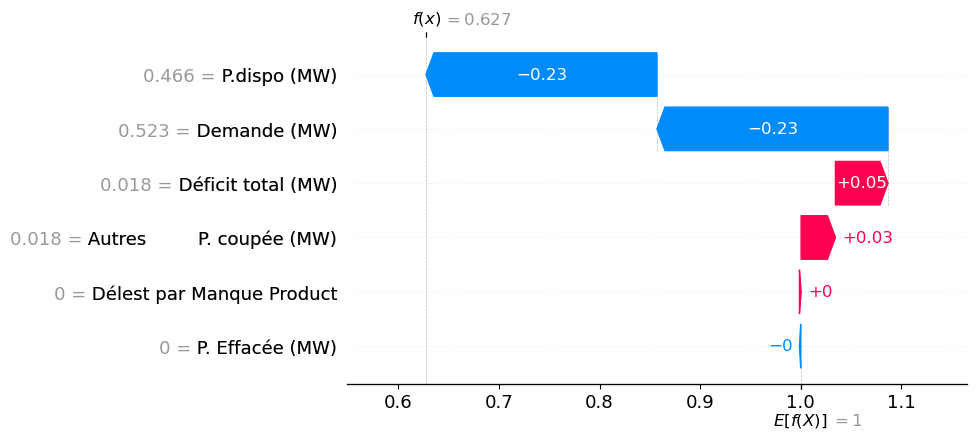

In [87]:
# 🔥 Création du graphique waterfall pour la 1re instance
i = 3  # ou n'importe quelle ligne que tu veux analyser

shap.plots.waterfall(shap.Explanation(
    values=shap_values[i, :, 1],  # Valeurs SHAP pour l'instance i et classe 1
    base_values=explainer.expected_value[1],  # Valeur de base pour la classe 1
    data=X_val.iloc[i].values,  # Données originales de l'instance
    feature_names=X_val.columns.tolist()
))


##### INTERPRETATION

cette figure est un diagramme de Waterfall (ou en cascade) utilisé pour visualiser la contribution de différentes variables à la prédiction d'un modèle. Voyons ensemble ce qu'elle nous dit :

Valeur de base (E[f(X)] = 1) : Le point de départ, la valeur attendue de la prédiction en l'absence de toute information sur les variables spécifiques. Ici, elle est de 1.

f(x) = 0.568 : C'est la prédiction finale du modèle pour cette instance particulière. On voit donc que les variables ont globalement un impact négatif sur la prédiction, la faisant diminuer de 1 à 0.568.

P.dispo (MW) = 0.366 : La disponibilité de puissance (P.dispo) a un impact négatif de -0.27 sur la prédiction. Cela suggère qu'une disponibilité de puissance plus élevée tend à diminuer la valeur prédite.

Demande (MW) = 0.147 : La demande a également un impact négatif de -0.27 sur la prédiction. Une demande plus élevée semble également associée à une diminution de la valeur prédite.

Déficit total (MW) = 0 : Un déficit total nul a un impact positif de +0.06 sur la prédiction. Cela indique qu'en l'absence de déficit total, la valeur prédite a tendance à augmenter.

Autres P. coupée (MW) = 0 : La variable "Autres P. coupée" (autre puissance coupée) à une valeur de zéro a un impact positif de +0.04 sur la prédiction. Similaire au déficit total, une absence de cette puissance coupée contribue à augmenter la prédiction.

Délest par Manque Product = 0 : Le délestage par manque de production, lorsqu'il est nul, a un impact neutre (+0) sur la prédiction.

P. Effacée (MW) = 0 : La puissance effacée, lorsqu'elle est nulle, a un impact légèrement négatif de -0.01 sur la prédiction.

En résumé :

Les variables de disponibilité de puissance et de demande ont le plus fort impact négatif sur la prédiction. L'absence de déficit total et d'autres puissances coupées ont un impact positif, compensant partiellement la diminution causée par la disponibilité et la demande. Le délestage par manque de production n'a pas d'impact dans ce cas, et l'absence de puissance effacée a un léger impact négatif.

Pour une compréhension plus approfondie, il serait utile de connaître le contexte de cette prédiction. Quelle est la variable cible que le modèle essaie de prédire ? Cela nous aiderait à interpréter le sens de ces impacts.


📊 Waterfall plot pour l'instance 0


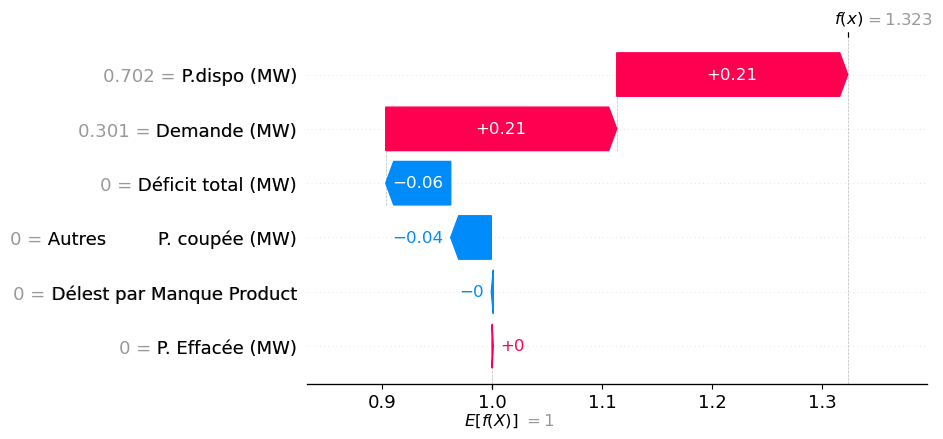


📊 Waterfall plot pour l'instance 3


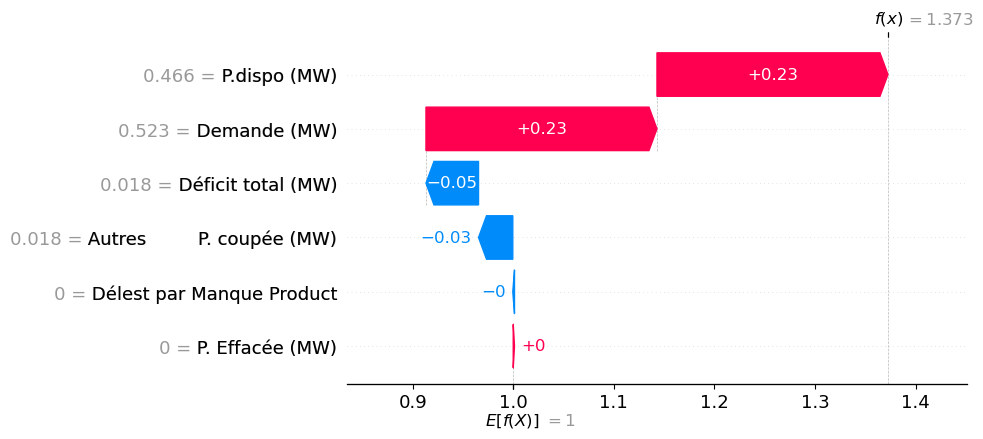


📊 Waterfall plot pour l'instance 7


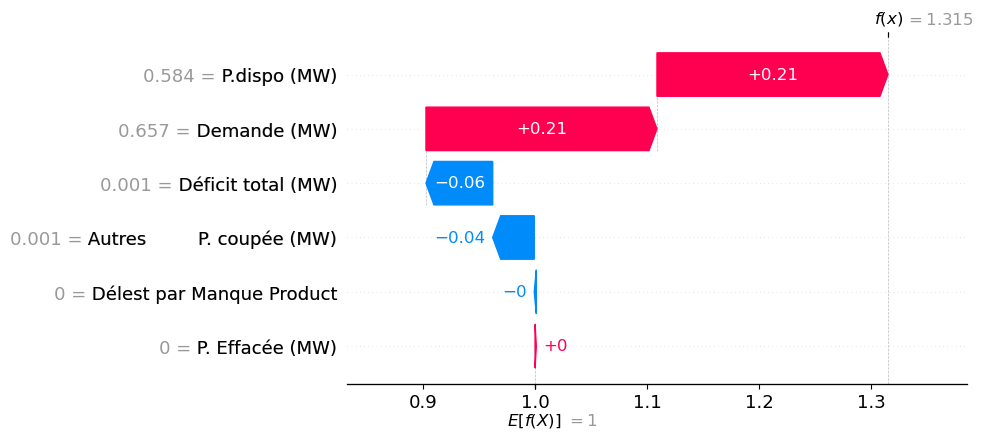

In [88]:
def waterfall_all_instances(shap_values, X_val, feature_names, base_value, indices=None):
    if indices is None:
        indices = range(5)  # Par défaut, les 5 premières

    for i in indices:
        print(f"\n📊 Waterfall plot pour l'instance {i}")
        shap.plots.waterfall(shap.Explanation(
            values=shap_values[i, :, 0],
            base_values=base_value,
            data=X_val.iloc[i].values,
            feature_names=feature_names
        ))

waterfall_all_instances(shap_values, X_val, X_val.columns.tolist(), explainer.expected_value[1], indices=[0, 3, 7])

sample weighting

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

# y contient les vraies classes
sample_weights = compute_sample_weight(class_weight='balanced', y=train_labels)

#weights = np.where(train_labels == 0, 2, 1)  # 5x plus de poids pour classe 1
#weights = np.array(weights).flatten()


# dictionnaire des hyperparametres
param_hyper = {'C': [0.001,0.01,1,50,100,500]}

#Objet GridSearchcv
grid_logie_sample = GridSearchCV(estimator=LogisticRegression(
    random_state=seed,max_iter=500),param_grid = param_hyper,scoring ='f1', cv = 5,verbose=0)
# Entraiment du modele
logi_modele_samlpe = grid_logie_sample.fit(train_features,train_labels,sample_weight=sample_weights)


#model.fit(X_train, y_train, sample_weight=sample_weights)
pred_sample = modele_log_evalution(logi_modele_samlpe.best_estimator_,X_val,y_val)#,sample_weights=sample_weights)

              precision    recall  f1-score   support

           0       0.41      0.51      0.45       356
           1       0.67      0.58      0.63       621

    accuracy                           0.56       977
   macro avg       0.54      0.55      0.54       977
weighted avg       0.58      0.56      0.56       977



F1-score: 0.63
La precision est : 0.58
 Le rappel : 0.67


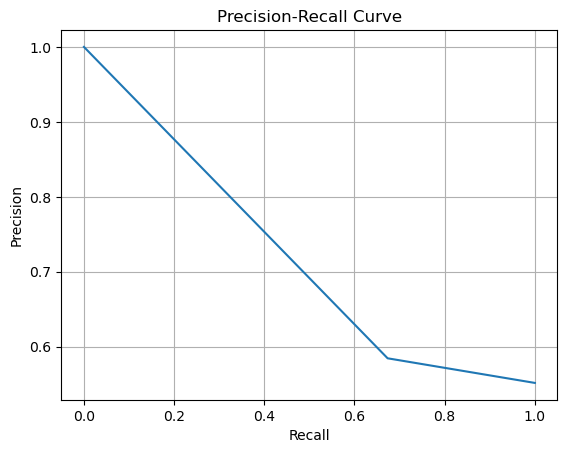

In [ ]:
performances(pred_sample,y_val,sample_weights=sample_weights)

##### REF

In [ ]:
rfe_logistique = model_with_ref(logi_modele.best_estimator_)
rfe_logistique

Index(['Délest par Manque Product', 'Autres         P. coupée (MW)',
       'Déficit total (MW)'],
      dtype='object')


RFE(estimator=LogisticRegression(C=100, max_iter=500, random_state=1111))

In [ ]:
tfe = modele_log_evalution(rfe_logistique,X_val,y_val)

              precision    recall  f1-score   support

           0       0.61      0.06      0.11       356
           1       0.65      0.98      0.78       621

    accuracy                           0.64       977
   macro avg       0.63      0.52      0.44       977
weighted avg       0.63      0.64      0.53       977



F1-score: 0.78
La precision est : 0.65
 Le rappel : 0.98


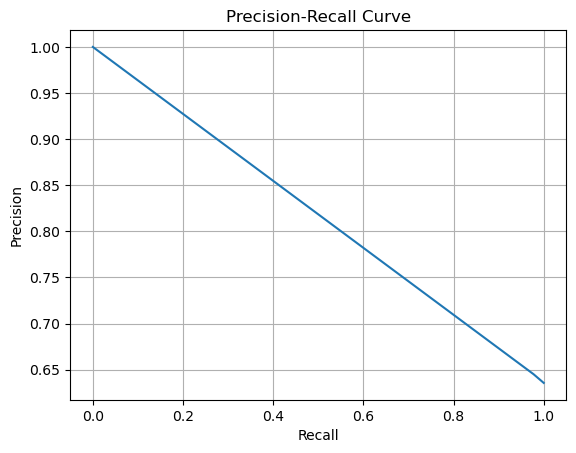

In [ ]:
performances(y_val,tfe)

##### les foret aleatoire

In [ ]:
param_grid_rf ={'n_estimators':[10,50,100,500,1000],
                'max_depth':[3,5,10,20,None]}

grid_rf_class = GridSearchCV(estimator= RandomForestClassifier(random_state=seed),
    param_grid = param_grid_rf,scoring = 'f1', cv =5
)
rf_model = grid_rf_class.fit(train_features,train_labels)

print(round(rf_model.best_score_,3))

print(rf_model.best_estimator_)

0.78
RandomForestClassifier(max_depth=10, n_estimators=500, random_state=1111)


In [ ]:
modele_log_evalution(rf_model.best_estimator_,X_val,y_val)

              precision    recall  f1-score   support

           0       0.55      0.14      0.23       356
           1       0.65      0.93      0.77       621

    accuracy                           0.64       977
   macro avg       0.60      0.54      0.50       977
weighted avg       0.62      0.64      0.57       977



array([1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
rf = model_with_ref(rf_model.best_estimator_)
rf

Index(['P.dispo (MW)', 'Demande (MW)', 'Déficit total (MW)'], dtype='object')


RFE(estimator=RandomForestClassifier(max_depth=10, n_estimators=500,
                                     random_state=1111))

In [ ]:
rfe_pred = modele_log_evalution(rf,X_val,y_val)

              precision    recall  f1-score   support

           0       0.53      0.13      0.21       356
           1       0.65      0.93      0.77       621

    accuracy                           0.64       977
   macro avg       0.59      0.53      0.49       977
weighted avg       0.61      0.64      0.56       977



F1-score: 0.77
La precision est : 0.65
 Le rappel : 0.93


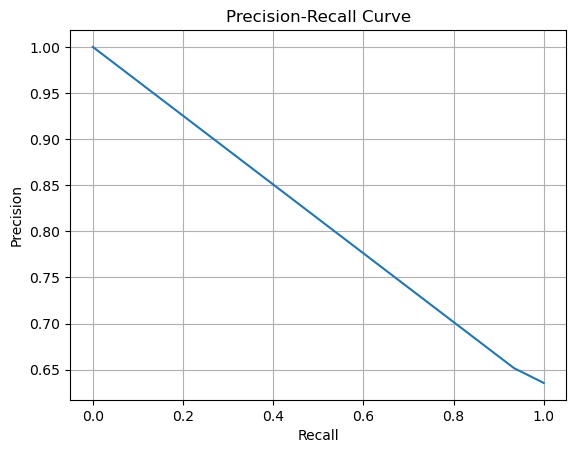

In [ ]:
performances(y_val,rfe_pred,sample_weights= None)

##### features importantes

In [ ]:
def mkdf(columns, importances):
    I = pd.DataFrame(data={'Feature':columns, 'Importance':importances})
    I = I.set_index('Feature')
    I = I.sort_values('Importance', ascending=True)
    return I

def plot_importances(df_importances, save=None, xrot=0, tickstep=3, scalefig=(1.0,1.0)):
    """
    Given an array or data frame of importances, plot a horizontal bar chart
    showing the importance values.
    """
    I = df_importances

    fig = plt.figure(figsize=(15,5))
    w, h = fig.get_size_inches()
    fig.set_size_inches(w*scalefig[0], h*scalefig[1], forward=True)
    ax = plt.gca()
    ax.barh(np.arange(len(I.index)), I.Importance, height=.7, tick_label=I.index)

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_aspect((x1 - x0) / (y1 - y0))

    # rotate x-ticks
    if xrot is not None:
        plt.xticks(rotation=xrot)
    # xticks freq
    xticks = ax.get_xticks()
    nticks = len(xticks)
    new_ticks = xticks[np.arange(0, nticks, step=tickstep)]
    ax.set_xticks(new_ticks)

    plt.tight_layout()
    plt.show()

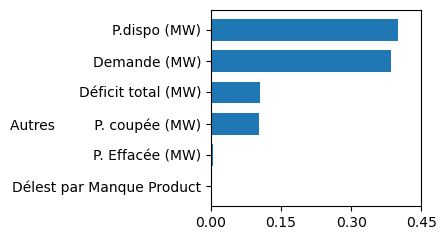

In [ ]:
I = mkdf(train_features.columns,rf_model.best_estimator_.feature_importances_)            
plot_importances(I, scalefig=(1.0,0.5))

In [ ]:
modele_log_evalution(rf_model.best_estimator_,X_val,y_val)